In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df=pd.read_csv('train.csv')
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [34]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [35]:
df.duplicated().sum()

0

In [36]:
# Distribution of duplicates and non duplicates
df['is_duplicate'].value_counts()

0    255027
1    149263
Name: is_duplicate, dtype: int64

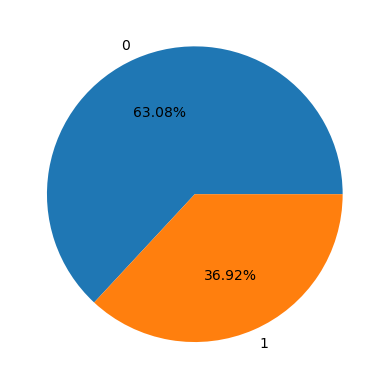

In [37]:
plt.pie(df['is_duplicate'].value_counts().values,labels=df['is_duplicate'].unique(),autopct='%0.2f%%');

In [38]:
# Repeated Questions
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print('Number of unique questions',np.unique(qid)[-1])
x=qid.value_counts()>1
print('Number of questions getting repeated ',x[x].shape[0])

Number of unique questions 537933
Number of questions getting repeated  111780


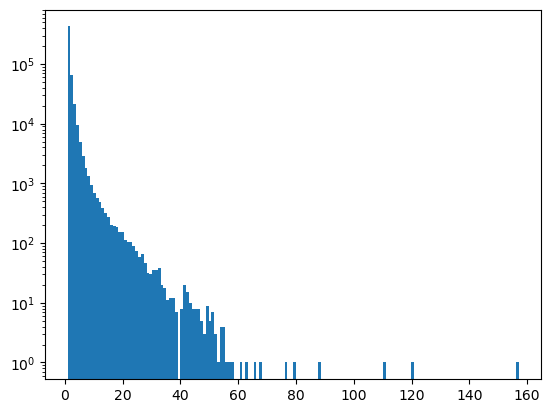

In [39]:
# Repeated questions Histogram
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log');

In [40]:
df['qid1'].nunique()+df['qid2'].nunique()

590018

In [41]:
df.dropna(axis=0,inplace=True)

In [42]:
df=df.sample(30000)

In [43]:
ques_df=df[['question1','question2']]
ques_df

,question1,question2
339348,Are there any good supplements to boost energy...,What is a good energy supplement which boosts ...
101419,What is the current salary average for a motio...,What is the current salary average for a senio...
367644,Are there any apps that can help me learn piano.,Onsite opportunities in Renault Nissan?
103758,If I remove someone from Snapchat and my accou...,"I blocked and unblocked someone on Snapchat, i..."
129505,How does one earn money online without an inve...,How can I earn money on internet?
...,...,...
54815,How do you study effectively?,What are some tricks to study effectively?
228487,Is the animal in this picture a muskrat or a b...,What are the most dramatic pictures of an anim...
58753,"Which is the healthiest place to eat in Pune, ...",Which Hinduism book mentions the caste system?
236977,The definition of electricity says it is the f...,What is the best name for a social cancer plat...


In [44]:
from sklearn.feature_extraction.text import CountVectorizer

In [45]:
questions=list(ques_df['question1'])+list(ques_df['question2']) # merge text
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [46]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)


In [47]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
339348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
101419,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
103758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129505,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54815,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
228487,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
58753,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
236977,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
temp_df['is_duplicate']=df['is_duplicate']

In [49]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
339348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
101419,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
103758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129505,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=0)

In [52]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [53]:
def build_model(hp):
    
    model=Sequential()
    counter=0
    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
        if counter==0:
            model.add(
                Dense(hp.Int('units'+str(i),min_value=8, max_value=128,step=8),
                     activation=hp.Choice('activation'+str(i),values=['relu','tanh','sigmoid']),
                     input_dim=6001))

        else:
             model.add(
                Dense(hp.Int('units'+str(i),min_value=8, max_value=128,step=8),
                     activation=hp.Choice('activation'+str(i),values=['relu','tanh','sigmoid'])))

                
        counter+=1
        
        

    model.add(Dense(1,activation='sigmoid'))
    
    
    model.compile(optimizer=hp.Choice('optimizer',values=['sgd','adam','rmsprop','adadelta','nadam']),
                                     loss='binary_crossentropy',
                                     metrics=['accuracy'])
 


    return model
     
            
            
        

In [54]:
import kerastuner as kt

In [55]:
tuner= kt.RandomSearch(build_model,objective='val_accuracy',
                       max_trials=3,
                       directory='my',
                       project_name='fi')

In [56]:
tuner.search(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Trial 2 Complete [00h 00m 01s]

Best val_accuracy So Far: None
Total elapsed time: 00h 00m 03s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
3                 |3                 |num_layers
32                |88                |units0
sigmoid           |relu              |activation0
adam              |rmsprop           |optimizer
96                |8                 |units1
sigmoid           |relu              |activation1
104               |8                 |units2
sigmoid           |relu              |activation2

Epoch 1/5


Traceback (most recent call last):
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\tuner.py", line 233, in _build_and_fit_model
    results = self.hypermodel.fit(hp, model, *args, **kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\hypermodel.py", line 149, in fit
    return model.fit(*args, **kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\utils\traceback_uti

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\tuner.py", line 233, in _build_and_fit_model
    results = self.hypermodel.fit(hp, model, *args, **kwargs)
  File "C:\Users\verma\anaconda3\lib\site-packages\keras_tuner\src\engine\hypermodel.py", line 149, in fit
    return model.fit(*args, **kwargs)
  File "C:

In [28]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 10,
 'units0': 120,
 'activation0': 'relu',
 'optimizer': 'adadelta',
 'units1': 8,
 'activation1': 'relu',
 'units2': 8,
 'activation2': 'relu',
 'units3': 8,
 'activation3': 'relu',
 'units4': 8,
 'activation4': 'relu',
 'units5': 8,
 'activation5': 'relu',
 'units6': 8,
 'activation6': 'relu',
 'units7': 8,
 'activation7': 'relu',
 'units8': 8,
 'activation8': 'relu',
 'units9': 8,
 'activation9': 'relu'}

In [30]:
model=tuner.get_best_models(num_models=1)[0]

NotFoundError: Unsuccessful TensorSliceReader constructor: Failed to find any matching files for mydir\final\trial_0\checkpoint

In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Define the model
model = Sequential()

# Add an RNN layer
model.add(SimpleRNN(units=64, input_shape=(6000, 1), return_sequences=True))

# Add a Dropout layer for regularization
model.add(Dropout(0.2))

# Add another RNN layer
model.add(SimpleRNN(units=32, return_sequences=True))

# Another Dropout layer
model.add(Dropout(0.2))

# Add a fully connected (Dense) layer
model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 6000, 64)          4224      
                                                                 
 dropout (Dropout)           (None, 6000, 64)          0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 6000, 32)          3104      
                                                                 
 dropout_1 (Dropout)         (None, 6000, 32)          0         
                                                                 
 dense_4 (Dense)             (None, 6000, 1)           33        
                                                                 
Total params: 7361 (28.75 KB)
Trainable params: 7361 (28.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [58]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [60]:
model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100


ValueError: in user code:

    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\training.py", line 1151, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\training.py", line 1209, in compute_loss
        return self.compiled_loss(
    File "C:\Users\verma\anaconda3\lib\site-packages\keras\src\engine\compile_utils.py", line 277, in __call__
        loss_value = loss_obj(y_t, y_p, samp

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

In [ ]:
y_pred_train=rf.predict(x_train)
y_pred=rf.predict(x_test)

In [ ]:
accuracy_score(y_pred_train,y_train)

In [ ]:
accuracy_score(y_pred,y_test)

In [118]:
from xgboost import XGBClassifier

In [119]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [120]:
y_pred_train=xgb.predict(x_train)
y_pred=xgb.predict(x_test)

In [121]:

accuracy_score(y_pred_train,y_train)

0.7735416666666667

In [122]:
accuracy_score(y_pred,y_test)

0.7218333333333333